# CS3807 – Deep Learning Laboratory
# Experiment 6: End-to-End Study of RNN, LSTM and GRU for Sequence Learning and Video Understanding

**Shiv Nadar University Chennai | B.Tech AI & DS | Semester V | AY 2026–27**

This notebook implements the complete pipeline specified in the experiment sheet:
- Part A: HAR sequence classification (Vanilla RNN vs LSTM vs GRU)
- Part B: Effect of sequence length
- Part C: Video understanding (CNN + LSTM/GRU on UCF101 subset)
- Part D: Synthetic sequence-to-sequence (encoder–decoder) task

> **Note:** All numeric results, plots and inferences must be produced by actually running this
> notebook. Cells marked `# TODO (inference)` are for the student to fill in **after** execution.


## 0. Environment Setup

In [1]:
# Core libraries
import os, io, time, json, zipfile, random, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Output directory for all required figures (600 DPI)
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
DPI = 600

def savefig(fig, name):
    """Save a figure at 600 DPI into FIG_DIR."""
    path = os.path.join(FIG_DIR, f"{name}.png")
    fig.savefig(path, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {path}")

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Dataset: UCI HAR (Raw Inertial Signals)

Using the **raw inertial signal files** (not the precomputed 561-feature vectors), so that the
input tensor is $X \in \mathbb{R}^{N \times 128 \times 9}$ (128 time steps, 9 channels:
body acceleration xyz, body gyroscope xyz, total acceleration xyz).

Source: https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones


In [2]:
# Download and extract the UCI HAR dataset (raw inertial signals)
DATA_URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
DATA_DIR = "UCI_HAR_data"

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)
    zip_path = "har.zip"
    urllib.request.urlretrieve(DATA_URL, zip_path)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_DIR)
    # inner archive
    inner_zip = os.path.join(DATA_DIR, "UCI HAR Dataset.zip")
    if os.path.exists(inner_zip):
        with zipfile.ZipFile(inner_zip, "r") as z:
            z.extractall(DATA_DIR)

HAR_ROOT = os.path.join(DATA_DIR, "UCI HAR Dataset")
print(os.listdir(HAR_ROOT))


['train', 'README.txt', 'features.txt', 'features_info.txt', 'activity_labels.txt', 'test', '.DS_Store']


In [3]:
# The 9 raw inertial signal channels
SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

ACTIVITY_MAP = {
    1: "WALKING", 2: "WALKING_UPSTAIRS", 3: "WALKING_DOWNSTAIRS",
    4: "SITTING", 5: "STANDING", 6: "LAYING",
}

def load_split(split):
    """Load one split (train/test) as X:(N,128,9) and y:(N,)."""
    sig_dir = os.path.join(HAR_ROOT, split, "Inertial Signals")
    channels = []
    for sig in SIGNALS:
        fpath = os.path.join(sig_dir, f"{sig}_{split}.txt")
        channels.append(np.loadtxt(fpath))          # (N, 128)
    X = np.stack(channels, axis=-1)                  # (N, 128, 9)
    y = np.loadtxt(os.path.join(HAR_ROOT, split, f"y_{split}.txt")).astype(int)
    return X, y

X_train_raw, y_train_raw = load_split("train")
X_test_raw, y_test_raw = load_split("test")

# Pool both provided splits; we build our own controlled 70/15/15 split from this pool
X_pool = np.concatenate([X_train_raw, X_test_raw], axis=0)
y_pool = np.concatenate([y_train_raw, y_test_raw], axis=0)
print("Pool shape:", X_pool.shape, y_pool.shape)


Pool shape: (10299, 128, 9) (10299,)


In [4]:
# Recommended laboratory subset: ~3000 windows, all 6 classes, approx. balanced
N_SUBSET = 3000
per_class = N_SUBSET // 6

idx_selected = []
rng = np.random.RandomState(SEED)
for c in range(1, 7):
    class_idx = np.where(y_pool == c)[0]
    chosen = rng.choice(class_idx, size=min(per_class, len(class_idx)), replace=False)
    idx_selected.append(chosen)
idx_selected = np.concatenate(idx_selected)
rng.shuffle(idx_selected)

X_subset = X_pool[idx_selected]
y_subset = y_pool[idx_selected]
print("Subset shape:", X_subset.shape, "| class counts:",
      dict(zip(*np.unique(y_subset, return_counts=True))))


Subset shape: (3000, 128, 9) | class counts: {np.int64(1): np.int64(500), np.int64(2): np.int64(500), np.int64(3): np.int64(500), np.int64(4): np.int64(500), np.int64(5): np.int64(500), np.int64(6): np.int64(500)}


## 2. Preprocessing

Steps: encode labels → 70/15/15 split → normalize using **training statistics only** → verify shapes/class balance.


In [5]:
# Label encoding (1-6 -> 0-5)
le = LabelEncoder()
y_encoded = le.fit_transform(y_subset)          # classes sorted 1..6 -> 0..5
class_names = [ACTIVITY_MAP[c] for c in le.classes_]
print("Classes:", class_names)

# Train / Val / Test split: 70 / 15 / 15 (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_subset, y_encoded, test_size=0.30, stratify=y_encoded, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

# Normalization using TRAINING statistics only (per-channel)
train_mean = X_train.mean(axis=(0, 1), keepdims=True)
train_std = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

X_train_n = (X_train - train_mean) / train_std
X_val_n   = (X_val   - train_mean) / train_std
X_test_n  = (X_test  - train_mean) / train_std


Classes: ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


In [6]:
# Expected preprocessing output
print("Input tensor shape:")
print(f"  Training   : {X_train_n.shape}")
print(f"  Validation : {X_val_n.shape}")
print(f"  Testing    : {X_test_n.shape}")
print()
print("Number of classes:", len(class_names))
print("Number of features per time step:", X_train_n.shape[-1])
print("Sequence length:", X_train_n.shape[1])
print()
print("Class distribution (train):", dict(zip(*np.unique(y_train, return_counts=True))))
print("Class distribution (val)  :", dict(zip(*np.unique(y_val, return_counts=True))))
print("Class distribution (test) :", dict(zip(*np.unique(y_test, return_counts=True))))


Input tensor shape:
  Training   : (2100, 128, 9)
  Validation : (450, 128, 9)
  Testing    : (450, 128, 9)

Number of classes: 6
Number of features per time step: 9
Sequence length: 128

Class distribution (train): {np.int64(0): np.int64(350), np.int64(1): np.int64(350), np.int64(2): np.int64(350), np.int64(3): np.int64(350), np.int64(4): np.int64(350), np.int64(5): np.int64(350)}
Class distribution (val)  : {np.int64(0): np.int64(75), np.int64(1): np.int64(75), np.int64(2): np.int64(75), np.int64(3): np.int64(75), np.int64(4): np.int64(75), np.int64(5): np.int64(75)}
Class distribution (test) : {np.int64(0): np.int64(75), np.int64(1): np.int64(75), np.int64(2): np.int64(75), np.int64(3): np.int64(75), np.int64(4): np.int64(75), np.int64(5): np.int64(75)}


## 3. Temporal Data Visualization — Plot 1

Sensor signal vs. time step for representative sequences from 3 different activity classes,
across 3 representative channels.


Saved: figures/plot1_sensor_signals.png


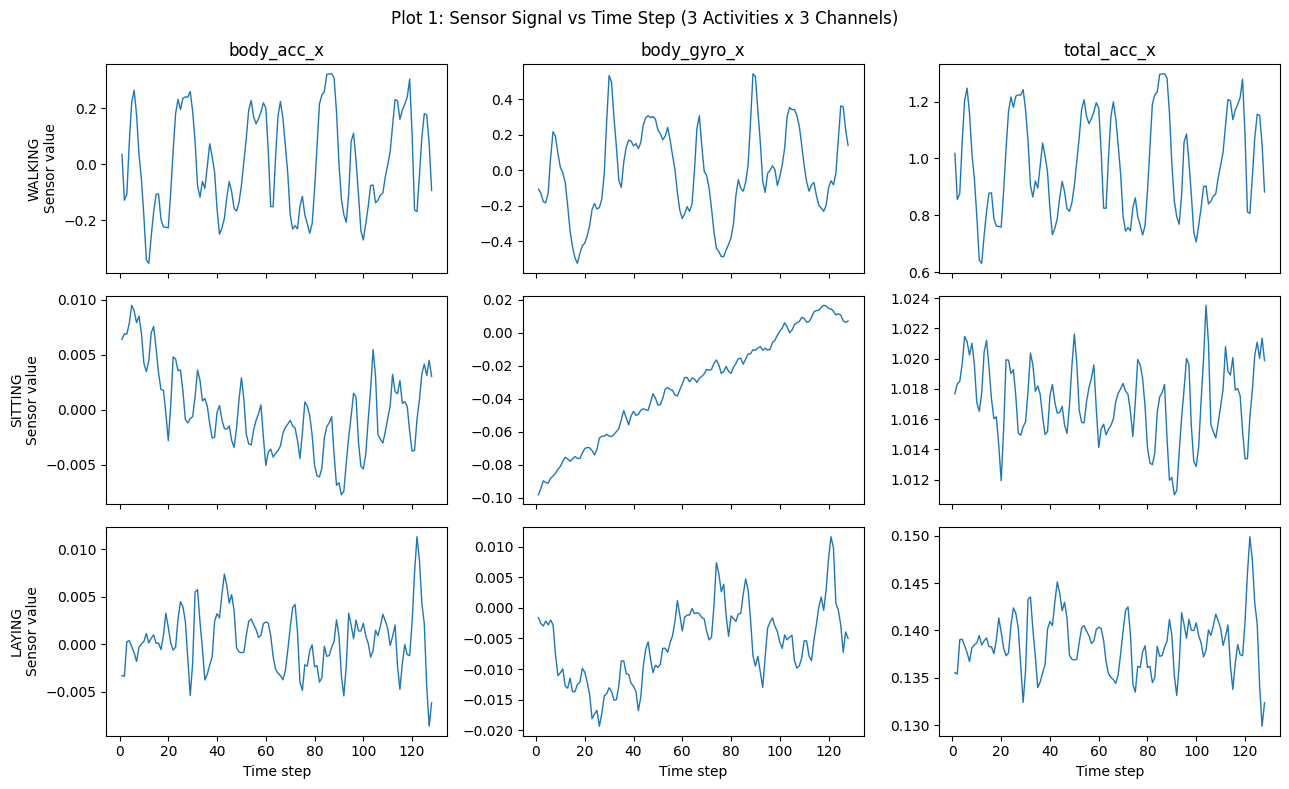

In [7]:
# Plot 1: Sensor signal vs time (3 activities x 3 channels)
chosen_activities = ["WALKING", "SITTING", "LAYING"]   # 3 representative classes
chosen_channels_idx = [0, 3, 6]                          # body_acc_x, body_gyro_x, total_acc_x
chosen_channels_name = [SIGNALS[i] for i in chosen_channels_idx]

fig, axes = plt.subplots(len(chosen_activities), len(chosen_channels_idx),
                          figsize=(13, 8), sharex=True)

for i, act in enumerate(chosen_activities):
    act_label = class_names.index(act)
    sample_idx = np.where(y_train == act_label)[0][0]
    sequence = X_train[sample_idx]   # unnormalized, for interpretability
    for j, ch in enumerate(chosen_channels_idx):
        ax = axes[i, j]
        ax.plot(np.arange(1, 129), sequence[:, ch], linewidth=1)
        if i == 0:
            ax.set_title(chosen_channels_name[j])
        if j == 0:
            ax.set_ylabel(f"{act}\nSensor value")
        if i == len(chosen_activities) - 1:
            ax.set_xlabel("Time step")

fig.suptitle("Plot 1: Sensor Signal vs Time Step (3 Activities x 3 Channels)")
fig.tight_layout()
savefig(fig, "plot1_sensor_signals")
plt.show()


**Required inference (TODO after running):**
1. What temporal pattern is visible?
2. Which activities exhibit similar patterns?
3. Why is the ordering of measurements important?


## 4. Vanilla RNN Architecture

Hidden state update: $h_t = \tanh(W_x x_t + W_h h_{t-1} + b_h)$
Output: $y_t = g(W_y h_t + b_y)$

For classification, the final hidden state $h_T$ is passed to a dense classifier.
The same recurrent weights $W_x, W_h$ are reused at every unrolled time step.

## 5. Backpropagation Through Time (BPTT)

BPTT propagates the loss gradient backward through every unrolled time step. Because this
involves repeated multiplication of derivatives, $\left\|\frac{\partial h_t}{\partial h_{t-k}}\right\| \to 0$
(vanishing) or diverges (exploding) for long sequences.

**Challenges:** vanishing gradients, exploding gradients, difficulty learning long-term
dependencies, limited parallelism (sequential computation).


In [8]:
# Numerical exercise: manually verify h1, h2, h3 using ht = tanh(Wx*xt + Wh*ht-1 + b)
x1, x2, x3 = 0.5, 0.7, 0.2
h0 = 0.0
Wx, Wh, b = 0.5, 0.8, 0.1

h1 = np.tanh(Wx * x1 + Wh * h0 + b)
h2 = np.tanh(Wx * x2 + Wh * h1 + b)
h3 = np.tanh(Wx * x3 + Wh * h2 + b)

print(f"h1 = {h1:.6f}")
print(f"h2 = {h2:.6f}")
print(f"h3 = {h3:.6f}")
print()
print("# TODO: compare these program-computed values with your hand-calculated values.")


h1 = 0.336376
h2 = 0.616352
h3 = 0.599958

# TODO: compare these program-computed values with your hand-calculated values.


## 6. LSTM Architecture

Gates: forget $f_t=\sigma(W_f[h_{t-1},x_t]+b_f)$, input $i_t=\sigma(W_i[h_{t-1},x_t]+b_i)$,
output $o_t=\sigma(W_o[h_{t-1},x_t]+b_o)$.
Candidate cell: $\tilde C_t=\tanh(W_C[h_{t-1},x_t]+b_C)$.
Cell state: $C_t=f_t C_{t-1}+i_t\tilde C_t$. Hidden state: $h_t=o_t\tanh(C_t)$.

The cell state $C_t$ acts as a memory highway that gates can selectively read from, write to,
or reset, allowing gradients to flow with less attenuation over long sequences.

## 7. GRU Architecture

Gates: update $z_t=\sigma(W_z[h_{t-1},x_t]+b_z)$, reset $r_t=\sigma(W_r[h_{t-1},x_t]+b_r)$.
Candidate: $\tilde h_t=\tanh(W_h[r_t\odot h_{t-1},x_t]+b_h)$.
Hidden state: $h_t=(1-z_t)h_{t-1}+z_t\tilde h_t$.

GRU merges the cell and hidden states and uses 2 gates instead of LSTM's 3, giving fewer
parameters at comparable representational power for many tasks.


## 8. RNN / LSTM / GRU Implementation

Same classifier head for all three models — only the recurrent layer changes, so the
comparison is controlled.

| Layer | Config |
|---|---|
| Recurrent (SimpleRNN/LSTM/GRU) | 32 units |
| Dropout | 0.2 |
| Dense | 16, ReLU |
| Dense (output) | 6, Softmax |

Optimizer: Adam (lr=1e-3) · Batch size: 32 · Epochs: 30 · Loss: sparse categorical cross-entropy


In [9]:
RECURRENT_LAYERS = {
    "RNN": layers.SimpleRNN,
    "LSTM": layers.LSTM,
    "GRU": layers.GRU,
}

def build_model(recurrent_type, seq_len, n_features, n_classes=6, units=32):
    """Build the classifier: Input -> Recurrent(units) -> Dropout(0.2) -> Dense(16,relu) -> Dense(n_classes,softmax)"""
    RecLayer = RECURRENT_LAYERS[recurrent_type]
    model = models.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        RecLayer(units),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name=f"{recurrent_type}_classifier")
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

def train_model(model, X_tr, y_tr, X_va, y_va, epochs=30, batch_size=32, verbose=0):
    start = time.time()
    history = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                         epochs=epochs, batch_size=batch_size, verbose=verbose)
    elapsed = time.time() - start
    return history, elapsed


In [10]:
# Train RNN, LSTM and GRU under identical conditions
EPOCHS = 30
BATCH_SIZE = 32
model_types = ["RNN", "LSTM", "GRU"]

trained_models, histories, train_times, param_counts = {}, {}, {}, {}

for mtype in model_types:
    print(f"Training {mtype} ...")
    model = build_model(mtype, seq_len=128, n_features=9, n_classes=6)
    history, elapsed = train_model(model, X_train_n, y_train, X_val_n, y_val,
                                    epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=1)
    trained_models[mtype] = model
    histories[mtype] = history
    train_times[mtype] = elapsed
    param_counts[mtype] = model.count_params()
    print(f"{mtype} done in {elapsed:.1f}s | params = {param_counts[mtype]}")


Training RNN ...
Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.3752 - loss: 1.6204 - val_accuracy: 0.5044 - val_loss: 1.3587
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4481 - loss: 1.3815 - val_accuracy: 0.5022 - val_loss: 1.1759
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4862 - loss: 1.2246 - val_accuracy: 0.5022 - val_loss: 1.1405
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5395 - loss: 1.0923 - val_accuracy: 0.6111 - val_loss: 0.9538
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5810 - loss: 0.9887 - val_accuracy: 0.6200 - val_loss: 0.8818
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5786 - loss: 0.9512 - val_accuracy: 0.6289 - val_loss: 0.8781
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6133 - loss: 0.8576 - val_accuracy: 0.6356 - val_loss: 0.8158
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6267 - loss: 0.8261 - val_acc

## 9. Training Curves — Plot 2 (Loss) & Plot 3 (Accuracy)

Combined figure: rows = {Loss, Accuracy}, columns = {RNN, LSTM, GRU}.


Saved: figures/plot2_3_training_curves.png


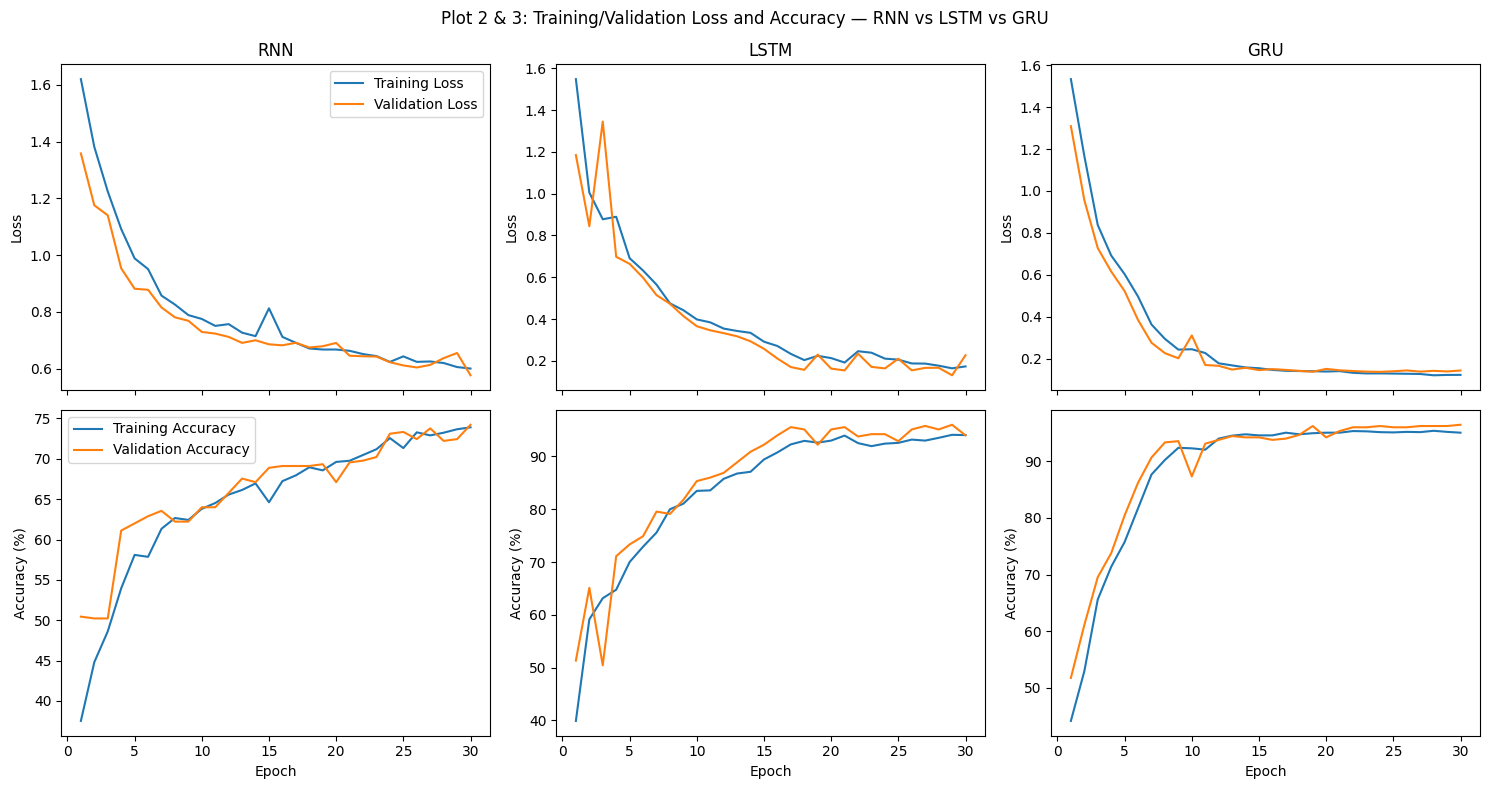

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)

for col, mtype in enumerate(model_types):
    hist = histories[mtype].history
    epochs_range = np.arange(1, len(hist["loss"]) + 1)

    # Row 0: Loss
    ax = axes[0, col]
    ax.plot(epochs_range, hist["loss"], label="Training Loss")
    ax.plot(epochs_range, hist["val_loss"], label="Validation Loss")
    ax.set_title(mtype)
    ax.set_ylabel("Loss")
    if col == 0:
        ax.legend()

    # Row 1: Accuracy (%)
    ax = axes[1, col]
    ax.plot(epochs_range, np.array(hist["accuracy"]) * 100, label="Training Accuracy")
    ax.plot(epochs_range, np.array(hist["val_accuracy"]) * 100, label="Validation Accuracy")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    if col == 0:
        ax.legend()

fig.suptitle("Plot 2 & 3: Training/Validation Loss and Accuracy — RNN vs LSTM vs GRU")
fig.tight_layout()
savefig(fig, "plot2_3_training_curves")
plt.show()


**Required inference (TODO after running):** convergence behavior, overfitting/underfitting,
generalization gap — for RNN, then LSTM, then GRU.


## 10. Performance Evaluation on Test Set

Mandatory metrics: accuracy, macro precision/recall/F1, confusion matrix, trainable parameters,
training time.


In [12]:
def evaluate_model(model, X_te, y_te):
    y_prob = model.predict(X_te, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    return {
        "accuracy": accuracy_score(y_te, y_pred) * 100,
        "precision": precision_score(y_te, y_pred, average="macro", zero_division=0) * 100,
        "recall": recall_score(y_te, y_pred, average="macro", zero_division=0) * 100,
        "f1": f1_score(y_te, y_pred, average="macro", zero_division=0) * 100,
        "y_pred": y_pred,
        "cm": confusion_matrix(y_te, y_pred),
    }

eval_results = {}
for mtype in model_types:
    eval_results[mtype] = evaluate_model(trained_models[mtype], X_test_n, y_test)

metrics_table = pd.DataFrame({
    mtype: {
        "Accuracy (%)": eval_results[mtype]["accuracy"],
        "Macro Precision (%)": eval_results[mtype]["precision"],
        "Macro Recall (%)": eval_results[mtype]["recall"],
        "Macro F1 (%)": eval_results[mtype]["f1"],
        "Parameters": param_counts[mtype],
        "Training Time (s)": train_times[mtype],
    } for mtype in model_types
}).T

metrics_table


,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
RNN,74.666667,75.357784,74.666667,74.469093,1974.0,29.982262
LSTM,92.666667,93.325102,92.666667,92.617688,6006.0,28.758473
GRU,95.777778,95.761235,95.777778,95.765467,4758.0,26.366017


## 11. Confusion Matrix Analysis — Plot 4

Saved: figures/plot4_confusion_matrices.png


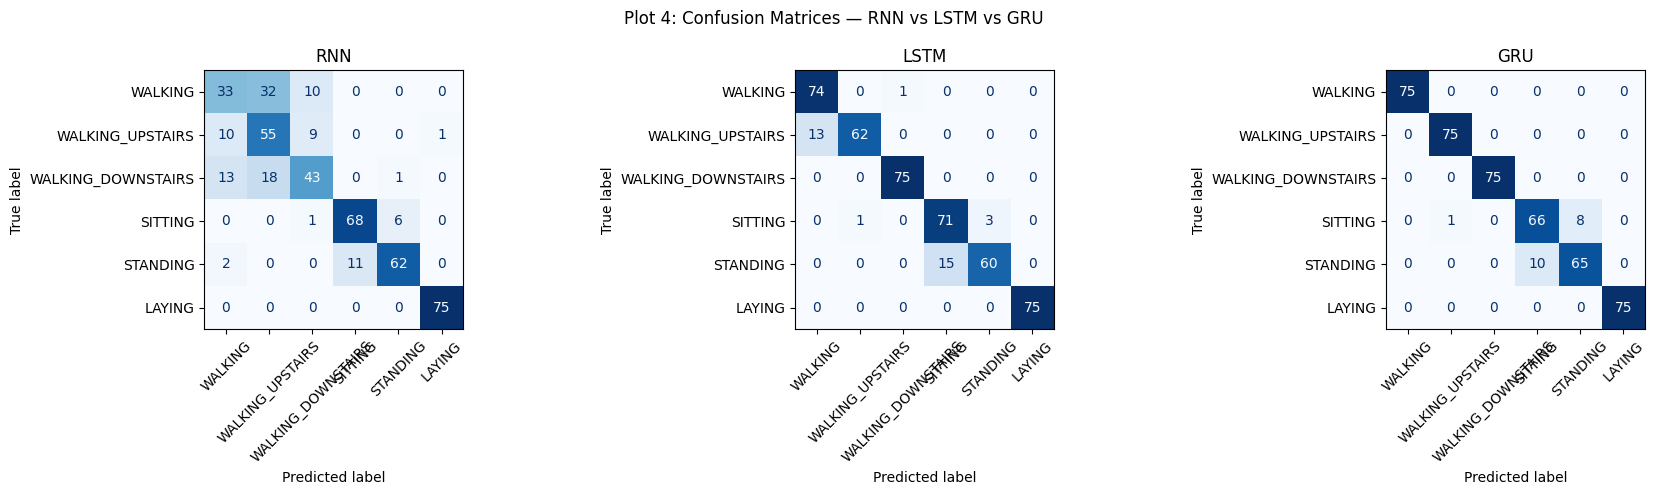

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, mtype in zip(axes, model_types):
    disp = ConfusionMatrixDisplay(eval_results[mtype]["cm"], display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=45, cmap="Blues")
    ax.set_title(mtype)

fig.suptitle("Plot 4: Confusion Matrices — RNN vs LSTM vs GRU")
fig.tight_layout()
savefig(fig, "plot4_confusion_matrices")
plt.show()


**Required inference (TODO after running):** activity with highest recognition rate;
activity with most misclassifications; commonly confused activity pairs; whether errors are
consistent across the three models.


## 12. RNN vs LSTM vs GRU — Comparison Table & Plot 5

In [14]:
comparison_table = pd.DataFrame({
    "Property": ["Hidden state", "Cell state", "Forget gate", "Input gate", "Output gate",
                 "Update gate", "Reset gate", "Parameters", "Training time (s)", "Test F1-score (%)"],
    "RNN":  ["Yes", "No", "No", "No", "No", "No", "No", param_counts["RNN"], f'{train_times["RNN"]:.1f}', f'{eval_results["RNN"]["f1"]:.2f}'],
    "LSTM": ["Yes", "Yes", "Yes", "Yes", "Yes", "No", "No", param_counts["LSTM"], f'{train_times["LSTM"]:.1f}', f'{eval_results["LSTM"]["f1"]:.2f}'],
    "GRU":  ["Yes", "No", "No", "No", "No", "Yes", "Yes", param_counts["GRU"], f'{train_times["GRU"]:.1f}', f'{eval_results["GRU"]["f1"]:.2f}'],
}).set_index("Property")

comparison_table


,RNN,LSTM,GRU
Property,,,
Hidden state,Yes,Yes,Yes
Cell state,No,Yes,No
Forget gate,No,Yes,No
Input gate,No,Yes,No
Output gate,No,Yes,No
Update gate,No,No,Yes
Reset gate,No,No,Yes
Parameters,1974,6006,4758
Training time (s),30.0,28.8,26.4


Saved: figures/plot5_model_comparison.png


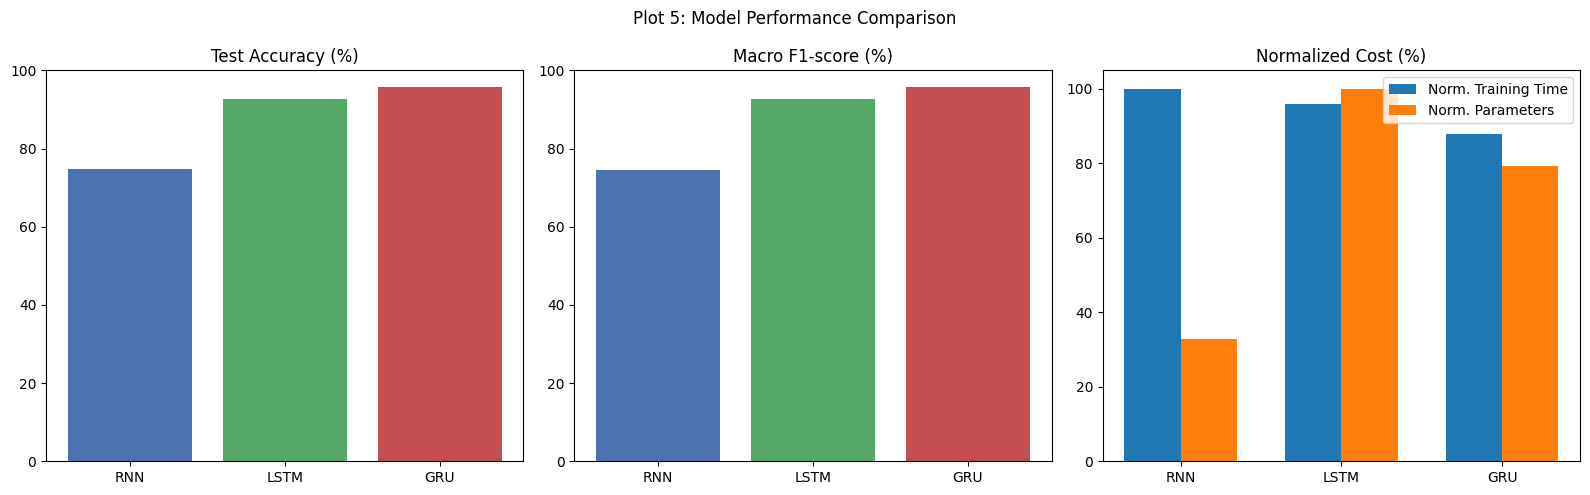

In [15]:
# Plot 5: Model performance comparison (Accuracy, Macro F1, normalized training time/params)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

acc_vals = [eval_results[m]["accuracy"] for m in model_types]
f1_vals = [eval_results[m]["f1"] for m in model_types]
norm_time = [train_times[m] / max(train_times.values()) * 100 for m in model_types]
norm_params = [param_counts[m] / max(param_counts.values()) * 100 for m in model_types]

axes[0].bar(model_types, acc_vals, color=["#4C72B0", "#55A868", "#C44E52"])
axes[0].set_title("Test Accuracy (%)"); axes[0].set_ylim(0, 100)

axes[1].bar(model_types, f1_vals, color=["#4C72B0", "#55A868", "#C44E52"])
axes[1].set_title("Macro F1-score (%)"); axes[1].set_ylim(0, 100)

width = 0.35
x = np.arange(len(model_types))
axes[2].bar(x - width/2, norm_time, width, label="Norm. Training Time")
axes[2].bar(x + width/2, norm_params, width, label="Norm. Parameters")
axes[2].set_xticks(x); axes[2].set_xticklabels(model_types)
axes[2].set_title("Normalized Cost (%)"); axes[2].legend()

fig.suptitle("Plot 5: Model Performance Comparison")
fig.tight_layout()
savefig(fig, "plot5_model_comparison")
plt.show()


**Required inference (TODO after running):** discuss the trade-off among predictive
performance, model complexity and training cost.


## 13. Effect of Sequence Length — Plot 6

Repeat training for $T \in \{32, 64, 128\}$ (truncating each 128-step window consistently to
its last $T$ steps) for all three recurrent models.


In [16]:
SEQ_LENGTHS = [32, 64, 128]
seqlen_results = {m: {} for m in model_types}
seqlen_times = {m: {} for m in model_types}   # NEW: training time per (model, T) -> Additional Exercise 5

for T in SEQ_LENGTHS:
    # Consistent truncation: keep the last T time steps of each window
    Xtr_T = X_train_n[:, -T:, :]
    Xva_T = X_val_n[:, -T:, :]
    Xte_T = X_test_n[:, -T:, :]

    for mtype in model_types:
        print(f"Training {mtype} | T={T} ...")
        model = build_model(mtype, seq_len=T, n_features=9, n_classes=6)
        _, elapsed = train_model(model, Xtr_T, y_train, Xva_T, y_val, epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
        res = evaluate_model(model, Xte_T, y_test)
        seqlen_results[mtype][T] = res["f1"]
        seqlen_times[mtype][T] = elapsed

seqlen_table = pd.DataFrame(seqlen_results)
seqlen_table.index.name = "Sequence Length"
print("Test macro F1-score (%) by sequence length:")
display(seqlen_table)

seqlen_time_table = pd.DataFrame(seqlen_times)
seqlen_time_table.index.name = "Sequence Length"
print("\nTraining time (s) by sequence length (Additional Exercise 5):")
display(seqlen_time_table)


Training RNN | T=32 ...
Training LSTM | T=32 ...
Training GRU | T=32 ...
Training RNN | T=64 ...
Training LSTM | T=64 ...
Training GRU | T=64 ...
Training RNN | T=128 ...
Training LSTM | T=128 ...
Training GRU | T=128 ...
Test macro F1-score (%) by sequence length:


,RNN,LSTM,GRU
Sequence Length,,,
32,81.003730,93.105295,93.778216
64,79.413222,94.631231,95.099465
128,76.600188,94.435346,94.651694



Training time (s) by sequence length (Additional Exercise 5):


,RNN,LSTM,GRU
Sequence Length,,,
32,19.372864,18.509145,17.839978
64,20.852009,20.023339,19.470194
128,28.208562,23.040201,23.205324


Saved: figures/plot6_seqlen_vs_f1.png


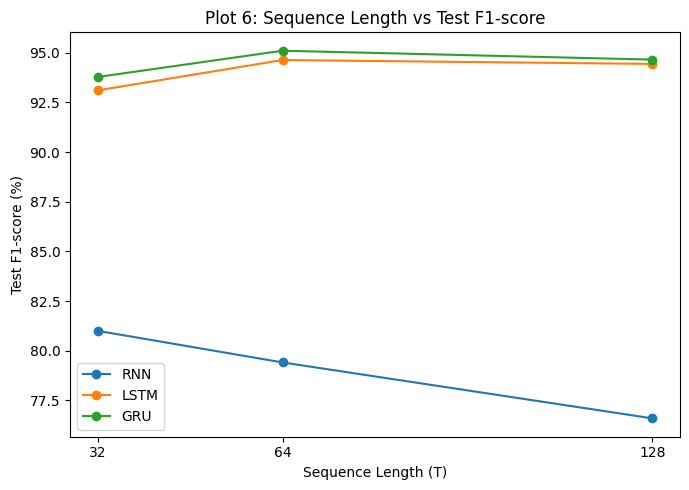

In [17]:
# Plot 6: Sequence length vs test F1-score
fig, ax = plt.subplots(figsize=(7, 5))
for mtype in model_types:
    ax.plot(SEQ_LENGTHS, [seqlen_results[mtype][T] for T in SEQ_LENGTHS], marker="o", label=mtype)
ax.set_xlabel("Sequence Length (T)")
ax.set_ylabel("Test F1-score (%)")
ax.set_title("Plot 6: Sequence Length vs Test F1-score")
ax.set_xticks(SEQ_LENGTHS)
ax.legend()
fig.tight_layout()
savefig(fig, "plot6_seqlen_vs_f1")
plt.show()


**Required inference (TODO after running):** how does the amount of temporal context
affect classification performance?


## 14. Video Understanding using CNN + RNN

Pipeline: Video → Frame Extraction → Pretrained CNN (frozen) → Frame Features → LSTM/GRU → Dense → Action.

**Manual dataset setup required before running the cells below:**
1. Download UCF101 from https://www.crcv.ucf.edu/data/UCF101.php (official `.rar` archive).
2. Extract it locally and pick **3–5 action classes** (e.g. `Basketball`, `Biking`, `Walking`,
   `Running`, `TennisSwing`) with a small number of videos per class.
3. Upload only the selected class folders to Colab (e.g. via Google Drive mount or direct
   upload) so that the following folder structure exists at `VIDEO_ROOT`:
   ```
   UCF101_subset/
     Basketball/*.avi
     Biking/*.avi
     Walking/*.avi
     ...
   ```
4. Update `VIDEO_ROOT` below to point to that folder, then run the cells.


In [18]:
from google.colab import drive
drive.mount('/content/drive')

# --- Point this to your manually prepared subset folder (see instructions above) ---
VIDEO_ROOT = "/content/drive/MyDrive/UCF101_subset"

# Verify if the VIDEO_ROOT directory exists
if os.path.isdir(VIDEO_ROOT):
    print(f"'{VIDEO_ROOT}' exists. Proceeding with video processing.")
    VIDEO_CLASSES = sorted(os.listdir(VIDEO_ROOT))
else:
    print(f"Warning: '{VIDEO_ROOT}' does not exist. Please check the path and ensure your Google Drive is mounted correctly and the folder structure matches.")
    VIDEO_CLASSES = []

print("Video classes found:", VIDEO_CLASSES)

Mounted at /content/drive
'/content/drive/MyDrive/UCF101_subset' exists. Proceeding with video processing.
Video classes found: ['IceDancing', 'WalkingWithDog', 'YoYo']


In [19]:
import cv2

N_FRAMES = 10
FRAME_SIZE = (224, 224)

def extract_frames(video_path, n_frames=N_FRAMES, size=FRAME_SIZE):
    """Uniformly sample n_frames from a video, resized to size x size x 3 (RGB, [0,1])."""
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return None
    indices = np.linspace(0, max(total - 1, 0), n_frames).astype(int)
    frames, idx_set, i = [], set(indices), 0
    while len(frames) < n_frames:
        ret, frame = cap.read()
        if not ret:
            break
        if i in idx_set:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, size)
            frames.append(frame.astype(np.float32) / 255.0)
        i += 1
    cap.release()
    if len(frames) < n_frames:
        return None
    return np.stack(frames, axis=0)   # (n_frames, 224, 224, 3)


In [20]:
# Build the raw video frame dataset from VIDEO_ROOT
video_paths, video_labels = [], []
for cls in VIDEO_CLASSES:
    cls_dir = os.path.join(VIDEO_ROOT, cls)
    for fname in os.listdir(cls_dir):
        if fname.lower().endswith((".avi", ".mp4", ".mov")):
            video_paths.append(os.path.join(cls_dir, fname))
            video_labels.append(cls)

video_le = LabelEncoder()
video_y = video_le.fit_transform(video_labels)
print(f"Total videos: {len(video_paths)} across {len(VIDEO_CLASSES)} classes")

video_frames = []
kept_idx = []
for i, p in enumerate(video_paths):
    frames = extract_frames(p)
    if frames is not None:
        video_frames.append(frames)
        kept_idx.append(i)

video_frames = np.stack(video_frames, axis=0)          # (num_videos, 10, 224, 224, 3)
video_y = video_y[kept_idx]
print("Frame tensor shape:", video_frames.shape)


Total videos: 45 across 3 classes
Frame tensor shape: (43, 10, 224, 224, 3)


### CNN Feature Extraction

MobileNetV2 (ImageNet weights, classification head removed) is used **only as a frozen feature
extractor** — it is not trained.


In [21]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

cnn_extractor = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")
cnn_extractor.trainable = False   # frozen

FEATURE_DIM = cnn_extractor.output_shape[-1]
print("CNN feature dimension D =", FEATURE_DIM)

def extract_cnn_features(frame_batch, batch_size=64):
    """frame_batch: (num_videos, n_frames, 224, 224, 3) -> (num_videos, n_frames, D)"""
    n_videos, n_frames = frame_batch.shape[:2]
    flat = frame_batch.reshape(-1, 224, 224, 3) * 255.0
    flat = preprocess_input(flat)
    feats = cnn_extractor.predict(flat, batch_size=batch_size, verbose=0)
    return feats.reshape(n_videos, n_frames, -1)

video_features = extract_cnn_features(video_frames)
print("Feature tensor shape supplied to recurrent network:", video_features.shape)


/tmp/ipykernel_1528/771171955.py:4: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  cnn_extractor = MobileNetV2(weights="imagenet", include_top=False, pooling="avg")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
CNN feature dimension D = 1280
Feature tensor shape supplied to recurrent network: (43, 10, 1280)


Saved: figures/plot7_video_frames.png


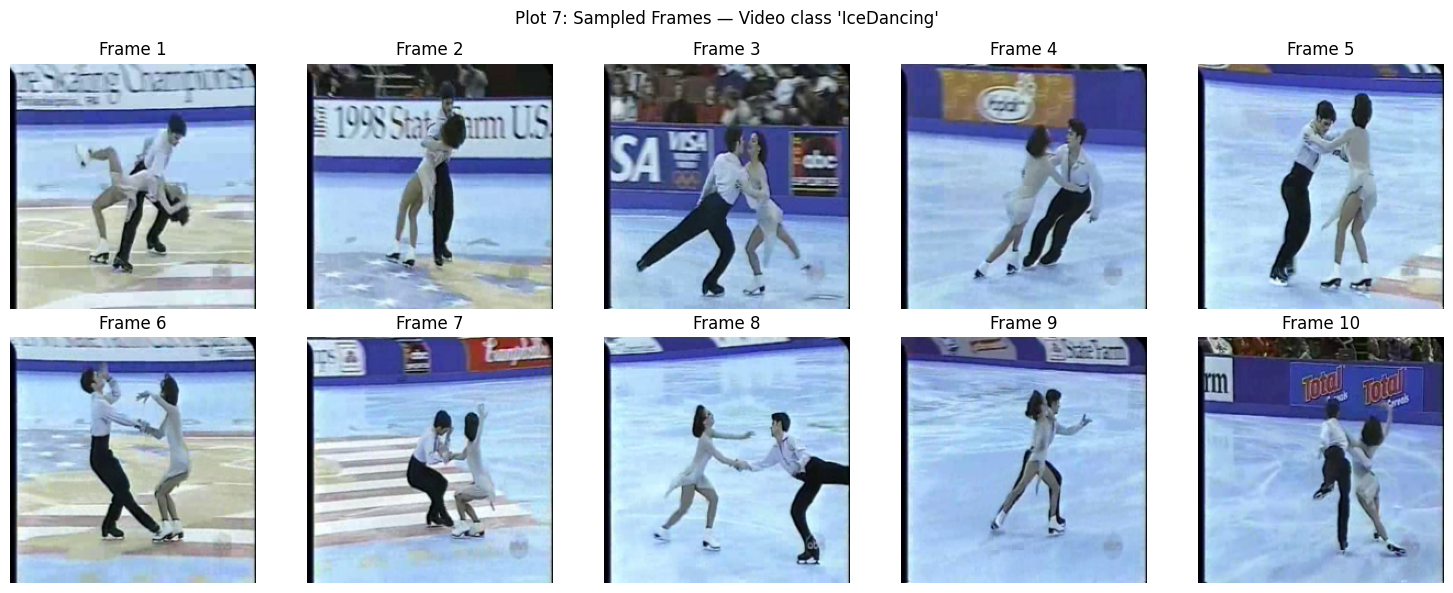

In [22]:
# Plot 7: Sample frames from one representative video
sample_i = 0
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(video_frames[sample_i, i])
    ax.set_title(f"Frame {i+1}")
    ax.axis("off")
fig.suptitle(f"Plot 7: Sampled Frames — Video class '{video_labels[kept_idx[sample_i]]}'")
fig.tight_layout()
savefig(fig, "plot7_video_frames")
plt.show()


### CNN–LSTM / CNN–GRU Classifier

Same builder function, sequence length = 10, feature dimension = $D$.


In [23]:
# Train/val/test split for the video task (stratified)
Xv_train, Xv_temp, yv_train, yv_temp = train_test_split(
    video_features, video_y, test_size=0.30, stratify=video_y, random_state=SEED)
Xv_val, Xv_test, yv_val, yv_test = train_test_split(
    Xv_temp, yv_temp, test_size=0.50, stratify=yv_temp, random_state=SEED)

video_model_types = ["LSTM", "GRU"]
video_models, video_histories, video_eval = {}, {}, {}

for mtype in video_model_types:
    print(f"Training CNN-{mtype} ...")
    vmodel = build_model(mtype, seq_len=N_FRAMES, n_features=FEATURE_DIM,
                          n_classes=len(VIDEO_CLASSES))
    hist, _ = train_model(vmodel, Xv_train, yv_train, Xv_val, yv_val,
                           epochs=EPOCHS, batch_size=min(BATCH_SIZE, len(Xv_train)), verbose=1)
    video_models[mtype] = vmodel
    video_histories[mtype] = hist
    video_eval[mtype] = evaluate_model(vmodel, Xv_test, yv_test)


Training CNN-LSTM ...
Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4000 - loss: 1.0997 - val_accuracy: 0.8333 - val_loss: 0.8825
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6667 - loss: 0.8525 - val_accuracy: 0.8333 - val_loss: 0.7187
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.8333 - loss: 0.6990 - val_accuracy: 1.0000 - val_loss: 0.5743
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 1.0000 - loss: 0.5081 - val_accuracy: 1.0000 - val_loss: 0.4471
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9667 - loss: 0.3574 - val_accuracy: 1.0000 - val_loss: 0.3362
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 1.0000 - loss: 0.3133 - val_accuracy: 1.0000 - val_loss: 0.2684
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 1.0000 - loss: 0.2259 - val_accuracy: 1.0000 - val_loss: 0.2159
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 1.0000 - loss: 0.1495 - val_accuracy: 1.0000

Training CNN-GRU ...
Epoch 1/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2667 - loss: 1.3174 - val_accuracy: 0.3333 - val_loss: 0.9795
Epoch 2/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.5000 - loss: 0.8883 - val_accuracy: 0.5000 - val_loss: 0.8271
Epoch 3/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.6333 - loss: 0.7450 - val_accuracy: 0.8333 - val_loss: 0.6766
Epoch 4/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7000 - loss: 0.6484 - val_accuracy: 1.0000 - val_loss: 0.5709
Epoch 5/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.9333 - loss: 0.5440 - val_accuracy: 1.0000 - val_loss: 0.5117
Epoch 6/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9667 - loss: 0.4780 - val_accuracy: 1.0000 - val_loss: 0.4743
Epoch 7/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9000 - loss: 0.4671 - val_accuracy: 1.0000 - val_loss: 0.4366
Epoch 8/30
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.9000 - loss: 0.4525 - val_accuracy: 1.000

Saved: figures/plot8_video_curves.png


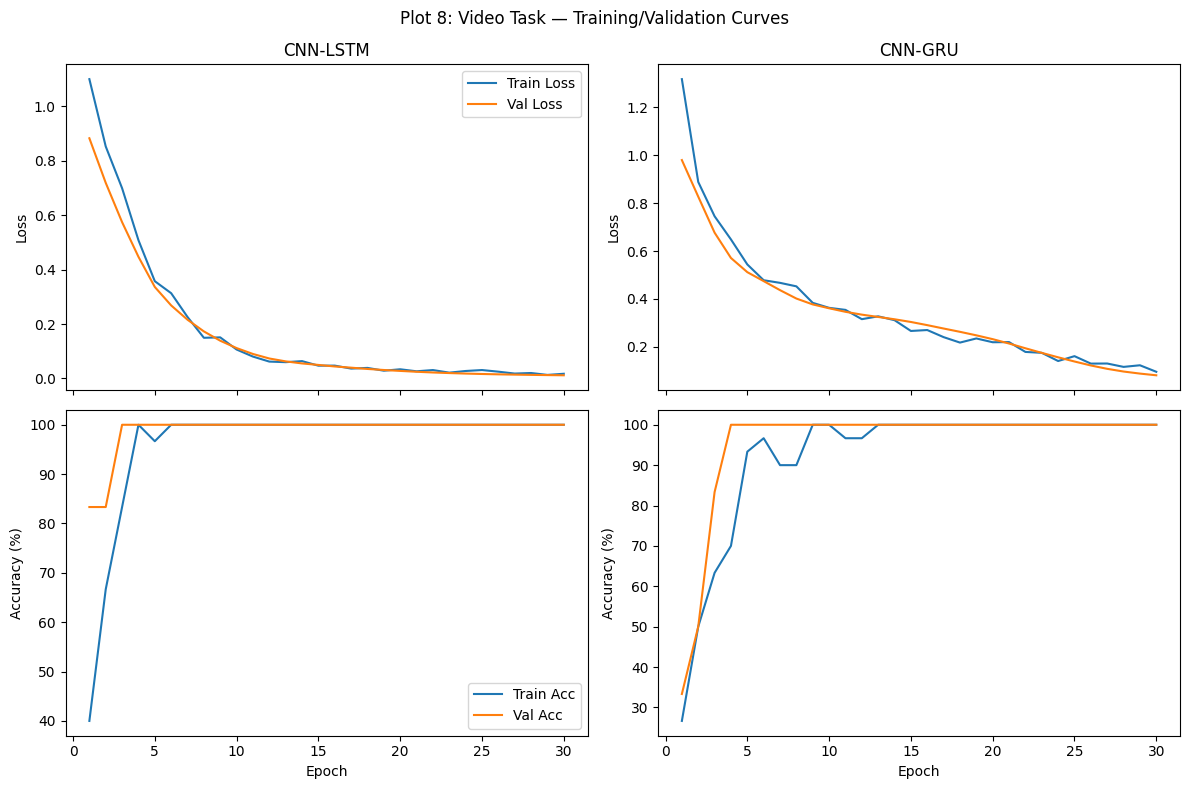

In [24]:
# Plot 8: Video training/validation curves (Loss + Accuracy) for CNN-LSTM and CNN-GRU
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for col, mtype in enumerate(video_model_types):
    hist = video_histories[mtype].history
    ep = np.arange(1, len(hist["loss"]) + 1)

    axes[0, col].plot(ep, hist["loss"], label="Train Loss")
    axes[0, col].plot(ep, hist["val_loss"], label="Val Loss")
    axes[0, col].set_title(f"CNN-{mtype}"); axes[0, col].set_ylabel("Loss")
    if col == 0: axes[0, col].legend()

    axes[1, col].plot(ep, np.array(hist["accuracy"]) * 100, label="Train Acc")
    axes[1, col].plot(ep, np.array(hist["val_accuracy"]) * 100, label="Val Acc")
    axes[1, col].set_xlabel("Epoch"); axes[1, col].set_ylabel("Accuracy (%)")
    if col == 0: axes[1, col].legend()

fig.suptitle("Plot 8: Video Task — Training/Validation Curves")
fig.tight_layout()
savefig(fig, "plot8_video_curves")
plt.show()


Saved: figures/plot9_video_confusion.png


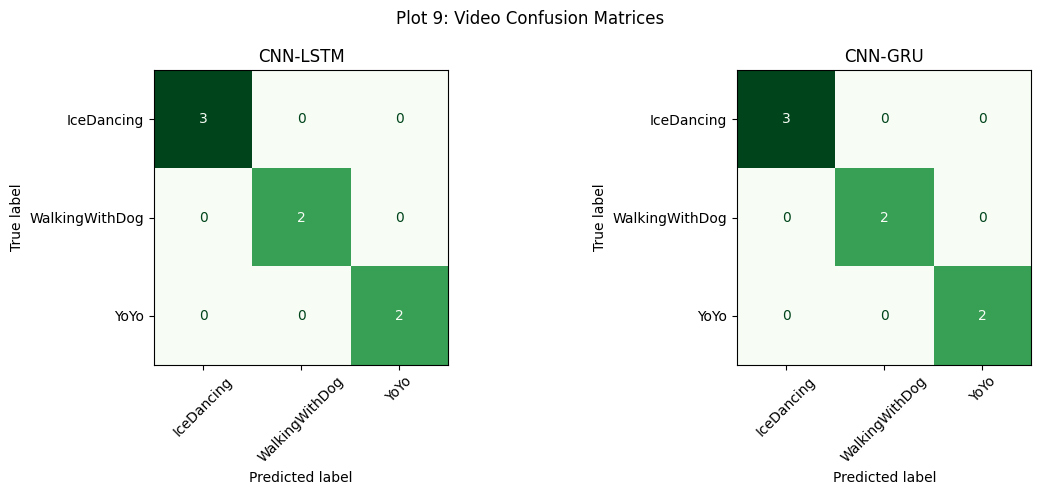

In [25]:
# Plot 9: Video confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mtype in zip(axes, video_model_types):
    disp = ConfusionMatrixDisplay(video_eval[mtype]["cm"], display_labels=VIDEO_CLASSES)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=45, cmap="Greens")
    ax.set_title(f"CNN-{mtype}")
fig.suptitle("Plot 9: Video Confusion Matrices")
fig.tight_layout()
savefig(fig, "plot9_video_confusion")
plt.show()


In [26]:
# Per-video predicted class, actual class and softmax confidence
# (required by the manual, Section 19 — must come from the trained model, not entered manually)
video_confidence_rows = []
for mtype in video_model_types:
    y_prob = video_models[mtype].predict(Xv_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    confidences = y_prob[np.arange(len(y_pred)), y_pred]
    for i in range(len(yv_test)):
        video_confidence_rows.append({
            "Model": f"CNN-{mtype}",
            "Test Video #": i + 1,
            "Predicted Class": VIDEO_CLASSES[y_pred[i]],
            "Actual Class": VIDEO_CLASSES[yv_test[i]],
            "Confidence": round(float(confidences[i]), 4),
        })

video_confidence_table = pd.DataFrame(video_confidence_rows)
video_confidence_table


,Model,Test Video #,Predicted Class,Actual Class,Confidence
0,CNN-LSTM,1,IceDancing,IceDancing,0.9915
1,CNN-LSTM,2,YoYo,YoYo,0.9843
2,CNN-LSTM,3,WalkingWithDog,WalkingWithDog,0.9780
3,CNN-LSTM,4,IceDancing,IceDancing,0.9900
4,CNN-LSTM,5,WalkingWithDog,WalkingWithDog,0.9828
5,CNN-LSTM,6,YoYo,YoYo,0.9845
6,CNN-LSTM,7,IceDancing,IceDancing,0.9906
7,CNN-GRU,1,IceDancing,IceDancing,0.8911
8,CNN-GRU,2,YoYo,YoYo,0.9779
9,CNN-GRU,3,WalkingWithDog,WalkingWithDog,0.9382


**Required inference (TODO after running):** what spatial information does the CNN
capture; what temporal information does the recurrent network learn; class-level and temporal
confusions observed.


## 15. Sequence-to-Sequence Learning — Synthetic Reversal Task

Task: map an input sequence of integers to its reverse, e.g. `[1,4,7,2] -> [2,7,4,1]`, using an
encoder–decoder (LSTM) architecture with teacher forcing.


In [27]:
# Generate synthetic reversal dataset
VOCAB_MIN, VOCAB_MAX = 1, 9      # integer range
SEQ2SEQ_LEN = 4                  # fixed sequence length
N_SAMPLES = 8000

VOCAB_SIZE = VOCAB_MAX + 2        # +1 for 0-index shift, +1 for <START> token
START_TOKEN = 0

def generate_reversal_data(n_samples, seq_len, vmin, vmax):
    X = np.random.randint(vmin, vmax + 1, size=(n_samples, seq_len))
    Y = X[:, ::-1].copy()
    return X, Y

X_seq, Y_seq = generate_reversal_data(N_SAMPLES, SEQ2SEQ_LEN, VOCAB_MIN, VOCAB_MAX)

# Decoder input = <START> + target shifted right (teacher forcing)
decoder_input = np.concatenate([np.full((N_SAMPLES, 1), START_TOKEN), Y_seq[:, :-1]], axis=1)

Xs_train, Xs_test, Ys_train, Ys_test, Din_train, Din_test = train_test_split(
    X_seq, Y_seq, decoder_input, test_size=0.15, random_state=SEED)


In [28]:
# Encoder-Decoder LSTM model
EMBED_DIM = 32
LSTM_UNITS = 64

enc_inputs = layers.Input(shape=(SEQ2SEQ_LEN,), name="encoder_input")
enc_emb = layers.Embedding(VOCAB_SIZE, EMBED_DIM)(enc_inputs)
enc_out, state_h, state_c = layers.LSTM(LSTM_UNITS, return_state=True, name="encoder_lstm")(enc_emb)
encoder_states = [state_h, state_c]

dec_inputs = layers.Input(shape=(SEQ2SEQ_LEN,), name="decoder_input")
dec_emb_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM)
dec_emb = dec_emb_layer(dec_inputs)
dec_lstm = layers.LSTM(LSTM_UNITS, return_sequences=True, return_state=True, name="decoder_lstm")
dec_out, _, _ = dec_lstm(dec_emb, initial_state=encoder_states)
dec_dense = layers.Dense(VOCAB_SIZE, activation="softmax", name="decoder_dense")
dec_pred = dec_dense(dec_out)

seq2seq_model = models.Model([enc_inputs, dec_inputs], dec_pred, name="encoder_decoder")
seq2seq_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
seq2seq_model.summary()


Model: "encoder_decoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4, 32)     │        352 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 4, 32)     │        352 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     24,832 │ embedding[0][0]   │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 4, 64),   │     24,832 │ embedding_1[0][0… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 4, 11)     │        715 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,083 (199.54 KB)

 Trainable params: 51,083 (199.54 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Train
seq2seq_history = seq2seq_model.fit(
    [Xs_train, Din_train], Ys_train,
    validation_split=0.1, epochs=30, batch_size=64, verbose=1)


Epoch 1/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3021 - loss: 1.9744 - val_accuracy: 0.4213 - val_loss: 1.4415
Epoch 2/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6737 - loss: 0.9181 - val_accuracy: 0.9438 - val_loss: 0.3910
Epoch 3/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9856 - loss: 0.2153 - val_accuracy: 0.9985 - val_loss: 0.1186
Epoch 4/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9991 - loss: 0.0828 - val_accuracy: 0.9993 - val_loss: 0.0600
Epoch 5/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9998 - loss: 0.0457 - val_accuracy: 0.9996 - val_loss: 0.0372
Epoch 6/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9999 - loss: 0.0293 - val_accuracy: 1.0000 - val_loss: 0.0261
Epoch 7/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 0.0203 - val_accuracy: 1.0000 - val_loss: 0.0183
Epoch 8/30
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 1.0000 - loss: 0.0149 - val_accuracy: 1.0000 - val_lo

In [30]:
# Inference: greedy decoding (step-by-step, using trained encoder/decoder states)
encoder_model = models.Model(enc_inputs, encoder_states)

dec_state_h_in = layers.Input(shape=(LSTM_UNITS,))
dec_state_c_in = layers.Input(shape=(LSTM_UNITS,))
dec_single_in = layers.Input(shape=(1,))
dec_single_emb = dec_emb_layer(dec_single_in)
dec_single_out, dec_h, dec_c = dec_lstm(dec_single_emb, initial_state=[dec_state_h_in, dec_state_c_in])
dec_single_pred = dec_dense(dec_single_out)
decoder_model = models.Model([dec_single_in, dec_state_h_in, dec_state_c_in],
                              [dec_single_pred, dec_h, dec_c])

def decode_sequence(input_seq):
    states = encoder_model.predict(input_seq[np.newaxis, :], verbose=0)
    target = np.array([[START_TOKEN]])
    output = []
    for _ in range(SEQ2SEQ_LEN):
        pred, h, c = decoder_model.predict([target] + states, verbose=0)
        token = np.argmax(pred[0, -1, :])
        output.append(token)
        target = np.array([[token]])
        states = [h, c]
    return np.array(output)


In [31]:
# Evaluate: token accuracy and sequence accuracy on the held-out test set
correct_tokens, total_tokens, correct_sequences = 0, 0, 0
predictions = []
for i in range(len(Xs_test)):
    pred_seq = decode_sequence(Xs_test[i])
    predictions.append(pred_seq)
    correct_tokens += np.sum(pred_seq == Ys_test[i])
    total_tokens += SEQ2SEQ_LEN
    correct_sequences += int(np.array_equal(pred_seq, Ys_test[i]))

token_accuracy = correct_tokens / total_tokens * 100
sequence_accuracy = correct_sequences / len(Xs_test) * 100

print(f"Token accuracy:    {token_accuracy:.2f}%")
print(f"Sequence accuracy: {sequence_accuracy:.2f}%")
print(f"Final training loss:   {seq2seq_history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {seq2seq_history.history['val_loss'][-1]:.4f}")


Token accuracy:    100.00%
Sequence accuracy: 100.00%
Final training loss:   0.0008
Final validation loss: 0.0009


In [32]:
# Display at least 5 test examples: input -> predicted output
examples = pd.DataFrame({
    "Sample": np.arange(1, 6),
    "Input Sequence": [list(Xs_test[i]) for i in range(5)],
    "Predicted Output": [list(predictions[i]) for i in range(5)],
    "Ground Truth": [list(Ys_test[i]) for i in range(5)],
})
examples


,Sample,Input Sequence,Predicted Output,Ground Truth
0,1,"[2, 2, 4, 6]","[6, 4, 2, 2]","[6, 4, 2, 2]"
1,2,"[8, 6, 3, 4]","[4, 3, 6, 8]","[4, 3, 6, 8]"
2,3,"[6, 3, 7, 7]","[7, 7, 3, 6]","[7, 7, 3, 6]"
3,4,"[1, 5, 1, 6]","[6, 1, 5, 1]","[6, 1, 5, 1]"
4,5,"[7, 2, 9, 8]","[8, 9, 2, 7]","[8, 9, 2, 7]"


**Required inference (TODO after running):** why can sequence-level accuracy be
substantially lower than token accuracy even when most individual tokens are correct?


## 16. Consolidated Results

In [33]:
consolidated = pd.DataFrame({
    m: {
        "Accuracy (%)": eval_results[m]["accuracy"],
        "Precision (%)": eval_results[m]["precision"],
        "Recall (%)": eval_results[m]["recall"],
        "F1 (%)": eval_results[m]["f1"],
        "Parameters": param_counts[m],
    } for m in model_types
}).T

# Append CNN-LSTM/GRU rows if the video section was run
for m in video_model_types:
    if m in video_eval:
        consolidated.loc[f"CNN-{m}"] = {
            "Accuracy (%)": video_eval[m]["accuracy"],
            "Precision (%)": video_eval[m]["precision"],
            "Recall (%)": video_eval[m]["recall"],
            "F1 (%)": video_eval[m]["f1"],
            "Parameters": video_models[m].count_params(),
        }

consolidated


,Accuracy (%),Precision (%),Recall (%),F1 (%),Parameters
RNN,74.666667,75.357784,74.666667,74.469093,1974.0
LSTM,92.666667,93.325102,92.666667,92.617688,6006.0
GRU,95.777778,95.761235,95.777778,95.765467,4758.0
CNN-LSTM,100.000000,100.000000,100.000000,100.000000,168643.0
CNN-GRU,100.000000,100.000000,100.000000,100.000000,126723.0


In [34]:
seq2seq_summary = pd.DataFrame({
    "Metric": ["Token Accuracy (%)", "Sequence Accuracy (%)", "Final Training Loss", "Final Validation Loss"],
    "Value": [token_accuracy, sequence_accuracy,
              seq2seq_history.history["loss"][-1], seq2seq_history.history["val_loss"][-1]],
})
seq2seq_summary


,Metric,Value
0,Token Accuracy (%),100.000000
1,Sequence Accuracy (%),100.000000
2,Final Training Loss,0.000799
3,Final Validation Loss,0.000868


## 17. Required Inferences — Checklist

Every plot above has a `**Required inference**` placeholder next to it. Confirm all are filled
in after running the notebook:

- [ ] Temporal pattern observed in the sensor signals (Plot 1)
- [ ] Convergence behavior of RNN (Plot 2/3)
- [ ] Convergence behavior of LSTM (Plot 2/3)
- [ ] Convergence behavior of GRU (Plot 2/3)
- [ ] Evidence of overfitting or underfitting (Plot 2/3)
- [ ] Activity-wise errors from the confusion matrix (Plot 4)
- [ ] Effect of sequence length (Plot 6)
- [ ] Parameter and computational differences among RNN, LSTM, GRU (Section 12, Plot 5)
- [ ] Role of CNN in video understanding (Section 14)
- [ ] Role of the recurrent model in temporal modeling (Section 14)
- [ ] Difference between token accuracy and sequence accuracy in seq2seq learning (Section 15)

Each inference should state: (1) what the plot shows, (2) the trend observed, (3) why it likely
occurs, (4) the conclusion drawn.


## 18. Discussion Questions\n\n**Q1.** What is a recurrent neural network?\n**A1.** _(answer here)_\n\n**Q2.** What information is represented by the hidden state?\n**A2.** _(answer here)_\n\n**Q3.** Why is sequence order important?\n**A3.** _(answer here)_\n\n**Q4.** Explain the difference between a feed-forward network and an RNN.\n**A4.** _(answer here)_\n\n**Q5.** Explain Backpropagation Through Time.\n**A5.** _(answer here)_\n\n**Q6.** Why can gradients vanish during BPTT?\n**A6.** _(answer here)_\n\n**Q7.** Why can gradients explode during BPTT?\n**A7.** _(answer here)_\n\n**Q8.** What are long-term dependencies?\n**A8.** _(answer here)_\n\n**Q9.** What is the role of the LSTM cell state?\n**A9.** _(answer here)_\n\n**Q10.** What are the forget, input and output gates in LSTM?\n**A10.** _(answer here)_\n\n**Q11.** What are the reset and update gates in GRU?\n**A11.** _(answer here)_\n\n**Q12.** Compare LSTM and GRU.\n**A12.** _(answer here)_\n\n**Q13.** Why does GRU generally use a simpler gating mechanism than LSTM?\n**A13.** _(answer here)_\n\n**Q14.** Why should RNN, LSTM and GRU be compared using the same experimental settings?\n**A14.** _(answer here)_\n\n**Q15.** What does the confusion matrix reveal that accuracy alone does not?\n**A15.** _(answer here)_\n\n**Q16.** Why should macro F1-score be reported for multi-class classification?\n**A16.** _(answer here)_\n\n**Q17.** What is the significance of sequence length?\n**A17.** _(answer here)_\n\n**Q18.** Why can a CNN be used as a feature extractor for video?\n**A18.** _(answer here)_\n\n**Q19.** What type of information is extracted by the CNN?\n**A19.** _(answer here)_\n\n**Q20.** What type of information is learned by the recurrent network?\n**A20.** _(answer here)_\n\n**Q21.** Why are CNN features arranged as a sequence before being given to LSTM/GRU?\n**A21.** _(answer here)_\n\n**Q22.** Explain the encoder and decoder in sequence-to-sequence learning.\n**A22.** _(answer here)_\n\n**Q23.** What is teacher forcing?\n**A23.** _(answer here)_\n\n**Q24.** Differentiate token accuracy and sequence accuracy.\n**A24.** _(answer here)_\n\n**Q25.** Why must the test set remain untouched during model selection?\n**A25.** _(answer here)_\n\n

## 19. Additional Exercises

1. Replace the 32 recurrent units with 16 and 64 units; study effect on accuracy, F1, parameter
   count and training time.
2. Compare GRU and LSTM using the same number of recurrent units.
3. Add a second recurrent layer and investigate whether performance improves.
4. Compare a bidirectional LSTM with a unidirectional LSTM.
5. Change the sequence length and study the effect on computational cost.
6. For the video task, compare LSTM and GRU after extracting identical CNN features (already
   done in Section 14 — summarize the comparison here).
7. Modify the seq2seq task so the output sequence has a different length from the input sequence.


### Additional Exercise 1: Effect of recurrent units (16 vs 64)

In [35]:
# ================= Additional Exercise 1: Effect of recurrent units (16 vs 64) =================
UNIT_VARIANTS = [16, 64]
unit_results = []

for units in UNIT_VARIANTS:
    for mtype in model_types:
        print(f"Training {mtype} with {units} units ...")
        model = build_model(mtype, seq_len=128, n_features=9, n_classes=6, units=units)
        _, elapsed = train_model(model, X_train_n, y_train, X_val_n, y_val,
                                  epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
        res = evaluate_model(model, X_test_n, y_test)
        unit_results.append({
            "Model": mtype, "Units": units,
            "Accuracy (%)": res["accuracy"], "Macro F1 (%)": res["f1"],
            "Parameters": model.count_params(), "Training Time (s)": elapsed,
        })

# Include the original 32-unit results (already trained in Section 8) for comparison
for mtype in model_types:
    unit_results.append({
        "Model": mtype, "Units": 32,
        "Accuracy (%)": eval_results[mtype]["accuracy"], "Macro F1 (%)": eval_results[mtype]["f1"],
        "Parameters": param_counts[mtype], "Training Time (s)": train_times[mtype],
    })

units_table = pd.DataFrame(unit_results).sort_values(["Model", "Units"]).reset_index(drop=True)
units_table


Training RNN with 16 units ...
Training LSTM with 16 units ...
Training GRU with 16 units ...
Training RNN with 64 units ...
Training LSTM with 64 units ...
Training GRU with 64 units ...


,Model,Units,Accuracy (%),Macro F1 (%),Parameters,Training Time (s)
0,GRU,16,94.888889,94.874687,1670,23.801668
1,GRU,32,95.777778,95.765467,4758,26.366017
2,GRU,64,95.111111,95.100476,15542,26.633559
3,LSTM,16,86.444444,86.432937,2038,29.487646
4,LSTM,32,92.666667,92.617688,6006,28.758473
5,LSTM,64,95.333333,95.318836,20086,25.102455
6,RNN,16,75.777778,75.616123,790,29.749392
7,RNN,32,74.666667,74.469093,1974,29.982262
8,RNN,64,81.555556,81.550982,5878,29.694826


### Additional Exercise 3: Second recurrent layer (stacked)

In [36]:
# ================= Additional Exercise 3: Second recurrent layer (stacked) =================
def build_stacked_model(recurrent_type, seq_len, n_features, n_classes=6, units=32):
    """Two stacked recurrent layers instead of one, same classifier head otherwise."""
    RecLayer = RECURRENT_LAYERS[recurrent_type]
    model = models.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        RecLayer(units, return_sequences=True),
        layers.Dropout(0.2),
        RecLayer(units),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name=f"{recurrent_type}_stacked")
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

stacked_results = []
for mtype in model_types:
    print(f"Training stacked (2-layer) {mtype} ...")
    model = build_stacked_model(mtype, seq_len=128, n_features=9, n_classes=6)
    _, elapsed = train_model(model, X_train_n, y_train, X_val_n, y_val,
                              epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
    res = evaluate_model(model, X_test_n, y_test)
    stacked_results.append({
        "Model": f"{mtype} (2-layer)", "Accuracy (%)": res["accuracy"], "Macro F1 (%)": res["f1"],
        "Parameters": model.count_params(), "Training Time (s)": elapsed,
    })
    stacked_results.append({
        "Model": f"{mtype} (1-layer, baseline)",
        "Accuracy (%)": eval_results[mtype]["accuracy"], "Macro F1 (%)": eval_results[mtype]["f1"],
        "Parameters": param_counts[mtype], "Training Time (s)": train_times[mtype],
    })

stacked_table = pd.DataFrame(stacked_results)
stacked_table


Training stacked (2-layer) RNN ...
Training stacked (2-layer) LSTM ...
Training stacked (2-layer) GRU ...


,Model,Accuracy (%),Macro F1 (%),Parameters,Training Time (s)
0,RNN (2-layer),67.333333,65.760358,4054,47.405402
1,"RNN (1-layer, baseline)",74.666667,74.469093,1974,29.982262
2,LSTM (2-layer),94.888889,94.859193,14326,35.960649
3,"LSTM (1-layer, baseline)",92.666667,92.617688,6006,28.758473
4,GRU (2-layer),95.555556,95.565593,11094,36.307767
5,"GRU (1-layer, baseline)",95.777778,95.765467,4758,26.366017


### Additional Exercise 4: Bidirectional vs Unidirectional LSTM

In [37]:
# ================= Additional Exercise 4: Bidirectional vs Unidirectional LSTM =================
def build_bilstm_model(seq_len, n_features, n_classes=6, units=32):
    model = models.Sequential([
        layers.Input(shape=(seq_len, n_features)),
        layers.Bidirectional(layers.LSTM(units)),
        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name="BiLSTM_classifier")
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

print("Training Bidirectional LSTM ...")
bilstm_model = build_bilstm_model(seq_len=128, n_features=9, n_classes=6)
_, bilstm_time = train_model(bilstm_model, X_train_n, y_train, X_val_n, y_val,
                              epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=0)
bilstm_res = evaluate_model(bilstm_model, X_test_n, y_test)

bilstm_table = pd.DataFrame([
    {"Model": "LSTM (unidirectional, baseline)",
     "Accuracy (%)": eval_results["LSTM"]["accuracy"], "Macro F1 (%)": eval_results["LSTM"]["f1"],
     "Parameters": param_counts["LSTM"], "Training Time (s)": train_times["LSTM"]},
    {"Model": "Bidirectional LSTM",
     "Accuracy (%)": bilstm_res["accuracy"], "Macro F1 (%)": bilstm_res["f1"],
     "Parameters": bilstm_model.count_params(), "Training Time (s)": bilstm_time},
])
bilstm_table


Training Bidirectional LSTM ...


,Model,Accuracy (%),Macro F1 (%),Parameters,Training Time (s)
0,"LSTM (unidirectional, baseline)",92.666667,92.617688,6006,28.758473
1,Bidirectional LSTM,95.555556,95.548367,11894,33.530825


### Additional Exercise 7: Seq2seq task with a different output length

In [38]:
# ================= Additional Exercise 7: Seq2seq with a different output length =================
# Task: input sequences of length 5; output = the first 3 input elements, reversed.
# (Input length != output length, unlike the main reversal task in Section 15.)
IN_LEN, OUT_LEN = 5, 3
N_SAMPLES_2 = 8000

def generate_diff_length_data(n_samples, in_len, out_len, vmin, vmax):
    X = np.random.randint(vmin, vmax + 1, size=(n_samples, in_len))
    Y = X[:, :out_len][:, ::-1].copy()
    return X, Y

X_seq2, Y_seq2 = generate_diff_length_data(N_SAMPLES_2, IN_LEN, OUT_LEN, VOCAB_MIN, VOCAB_MAX)
decoder_input2 = np.concatenate([np.full((N_SAMPLES_2, 1), START_TOKEN), Y_seq2[:, :-1]], axis=1)

Xs2_train, Xs2_test, Ys2_train, Ys2_test, Din2_train, Din2_test = train_test_split(
    X_seq2, Y_seq2, decoder_input2, test_size=0.15, random_state=SEED)

enc_in2 = layers.Input(shape=(IN_LEN,), name="encoder_input2")
enc_emb2 = layers.Embedding(VOCAB_SIZE, EMBED_DIM)(enc_in2)
_, sh2, sc2 = layers.LSTM(LSTM_UNITS, return_state=True, name="encoder_lstm2")(enc_emb2)
enc_states2 = [sh2, sc2]

dec_in2 = layers.Input(shape=(OUT_LEN,), name="decoder_input2")
dec_emb_layer2 = layers.Embedding(VOCAB_SIZE, EMBED_DIM)
dec_emb2 = dec_emb_layer2(dec_in2)
dec_lstm2 = layers.LSTM(LSTM_UNITS, return_sequences=True, return_state=True, name="decoder_lstm2")
dec_out2, _, _ = dec_lstm2(dec_emb2, initial_state=enc_states2)
dec_dense2 = layers.Dense(VOCAB_SIZE, activation="softmax", name="decoder_dense2")
dec_pred2 = dec_dense2(dec_out2)

seq2seq_model2 = models.Model([enc_in2, dec_in2], dec_pred2, name="encoder_decoder_diff_len")
seq2seq_model2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
seq2seq_history2 = seq2seq_model2.fit([Xs2_train, Din2_train], Ys2_train,
                                       validation_split=0.1, epochs=30, batch_size=64, verbose=0)

# Inference sub-models (same pattern as Section 15)
encoder_model2 = models.Model(enc_in2, enc_states2)
dsh_in2 = layers.Input(shape=(LSTM_UNITS,))
dsc_in2 = layers.Input(shape=(LSTM_UNITS,))
dsingle_in2 = layers.Input(shape=(1,))
dsingle_emb2 = dec_emb_layer2(dsingle_in2)
dsingle_out2, dh2, dc2 = dec_lstm2(dsingle_emb2, initial_state=[dsh_in2, dsc_in2])
dsingle_pred2 = dec_dense2(dsingle_out2)
decoder_model2 = models.Model([dsingle_in2, dsh_in2, dsc_in2], [dsingle_pred2, dh2, dc2])

def decode_sequence2(input_seq):
    states = encoder_model2.predict(input_seq[np.newaxis, :], verbose=0)
    target = np.array([[START_TOKEN]])
    output = []
    for _ in range(OUT_LEN):
        pred, h, c = decoder_model2.predict([target] + states, verbose=0)
        token = np.argmax(pred[0, -1, :])
        output.append(token)
        target = np.array([[token]])
        states = [h, c]
    return np.array(output)

correct_tok2, total_tok2, correct_seq2 = 0, 0, 0
preds2 = []
for i in range(len(Xs2_test)):
    p = decode_sequence2(Xs2_test[i])
    preds2.append(p)
    correct_tok2 += np.sum(p == Ys2_test[i])
    total_tok2 += OUT_LEN
    correct_seq2 += int(np.array_equal(p, Ys2_test[i]))

diff_len_token_acc = correct_tok2 / total_tok2 * 100
diff_len_seq_acc = correct_seq2 / len(Xs2_test) * 100

print(f"Input length {IN_LEN} -> Output length {OUT_LEN} (first {OUT_LEN} input elements, reversed)")
print(f"Token accuracy:    {diff_len_token_acc:.2f}%")
print(f"Sequence accuracy: {diff_len_seq_acc:.2f}%")

diff_len_examples = pd.DataFrame({
    "Sample": np.arange(1, 6),
    "Input Sequence": [list(Xs2_test[i]) for i in range(5)],
    "Predicted Output": [list(preds2[i]) for i in range(5)],
    "Ground Truth": [list(Ys2_test[i]) for i in range(5)],
})
diff_len_examples


Input length 5 -> Output length 3 (first 3 input elements, reversed)
Token accuracy:    100.00%
Sequence accuracy: 100.00%


,Sample,Input Sequence,Predicted Output,Ground Truth
0,1,"[8, 9, 7, 7, 2]","[7, 9, 8]","[7, 9, 8]"
1,2,"[8, 2, 7, 2, 1]","[7, 2, 8]","[7, 2, 8]"
2,3,"[9, 5, 3, 2, 9]","[3, 5, 9]","[3, 5, 9]"
3,4,"[4, 9, 5, 1, 9]","[5, 9, 4]","[5, 9, 4]"
4,5,"[9, 8, 1, 1, 2]","[1, 8, 9]","[1, 8, 9]"


## 20. Expected Outcome

**Sequence pipeline:** Sequential Data → Preprocessing → RNN/LSTM/GRU → Evaluation

**Video pipeline:** Video → Frames → CNN Features → LSTM/GRU → Action Prediction

**Encoder–decoder pipeline:** Input Sequence → Encoder → Context → Decoder → Output Sequence

All numeric results above must come from actually executing this notebook — none are assumed
in advance.


## 21. References

1. I. Goodfellow, Y. Bengio, A. Courville, *Deep Learning*, MIT Press, 2016.
2. S. Hochreiter, J. Schmidhuber, "Long Short-Term Memory," *Neural Computation*, 1997.
3. K. Cho et al., "Learning Phrase Representations using RNN Encoder–Decoder for Statistical
   Machine Translation," EMNLP, 2014.
4. Anguita et al., "A Public Domain Dataset for Human Activity Recognition Using Smartphones,"
   ESANN, 2013.
5. K. Soomro, A. R. Zamir, M. Shah, "UCF101: A Dataset of 101 Human Action Classes From Videos
   in the Wild," 2012.
6. TensorFlow Documentation: https://www.tensorflow.org
7. Keras Documentation: https://keras.io
